# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 12 - przekształcenia geometryczne






### Zadanie 1

1) Utwórz macierz współrzędnych punktów reprezentującą figurę geometryczną, składającą się z co najmniej 4 punktów. Figura powinna mieć "punkt centralny" znajdujący się (w przybliżeniu, nie musi być dokładnie) w punkcie `(0, 0)`.

2) Wyświetl utworzoną figurę na wykresie za pomocą biblioteki `matplotlib`. Upewnij się, że wykres jest czytelny (np. dodaj kolor wypełnienia figury i oznaczenia osi).

> Podpowiedź: możesz użyć funkcji [`plt.fill`](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.fill.html)

Kolejne zadania wykonuj, używając macierzy utworzonej w tym zadaniu, chyba że w treści zadania wskazano inaczej.


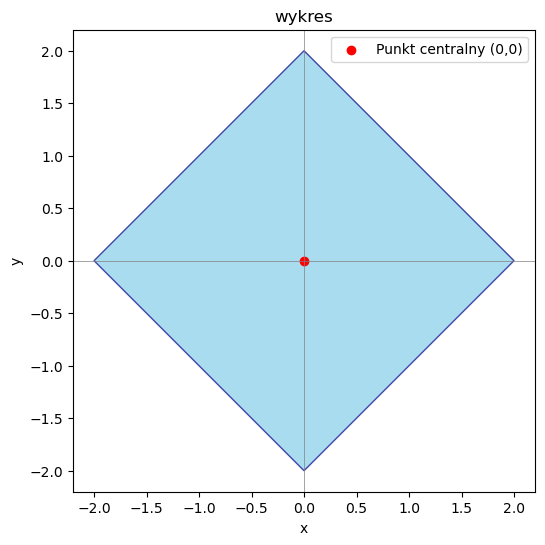

In [28]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([ 
    [0, 2],
    [2, 0],
    [0, -2],
    [-2, 0]
])

plt.figure(figsize=(6,6))
plt.fill(points[:,0], points[:,1], color='skyblue', alpha=0.7, edgecolor='navy')
plt.scatter(0, 0, color='red', label='Punkt centralny (0,0)')
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.gca().set_aspect('equal')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('wykres')
plt.show()

### Zadanie 2

Aby wykonać przekształcenie należy pomnożyć _macierz przekształcaną_ przez _macierz przekształcenia_. Poniżej wymienione są przykładowe macierze przekształceń pozwalające wykonać tranformacje:


Obrót o kąt $\theta$:

$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta\\
\text{sin}\theta & \text{cos}\theta
\end{pmatrix}
$$

Rozciągnięcie wzdłuż osi $0x$:

$$
A_k = \begin{pmatrix}
k & 0\\
0 & 1
\end{pmatrix}
$$

Rozciągnięcie wzdłuż osi $0y$:

$$
A_k = \begin{pmatrix}
1 & 0\\
0 & k
\end{pmatrix}
$$

Rozciągnięcie w proporcji $k_x$ wzdłuż osi $0x$ i w proporcji $k_y$ wzdłuż osi $0y$:

$$
A_k = \begin{pmatrix}
k_x & 0\\
0 & k_y
\end{pmatrix}
$$

Pochylenie względem osi $0y$:

$$
A_k = \begin{pmatrix}
1 & k\\
0 & 1
\end{pmatrix}
$$

Pochylenie względem osi $0x$:

$$
A_k = \begin{pmatrix}
1 & 0\\
k & 1
\end{pmatrix}
$$



**Polecenie**

Utwórz trzy animacje dla obrotu, rozciągnięcia i pochylenia (odpowiednio).


Przykład:

<div style="display: flex; flex-direction: row; flex-wrap: wrap; justify-content: center; width:100%;">
<img src="./Figure_2_rot.gif" height="300" width="300" />
<img src="./Figure_2_strech.gif" height="300" width="300" />
<img src="./Figure_2_shear.gif" height="300" width="300" />
</div>


Przykład tworzenia animacji:

```python
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np

fig, ax = plt.subplots(figsize=(8,8))

X = [1, 2, 3, 4]

def animate(i):
    ax.clear()
    ax.set_title(f'{i=}')
    ax.set_xlim(0,5)
    ax.set_ylim(1,10**16)
    ax.set_yscale('log')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.bar(X, [X[0]+i, X[1]*i, X[2]**i, i**X[3]] )

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=36, interval=100, repeat=True) 
ani.save('tmp.gif', writer='imagemagick', fps=100)
```

MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.
MovieWriter imagemagick unavailable; using Pillow instead.


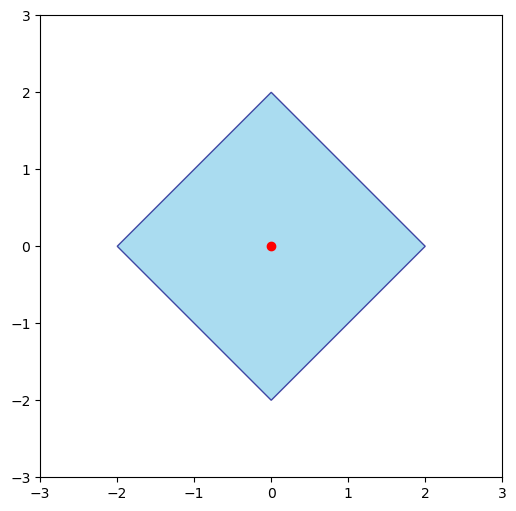

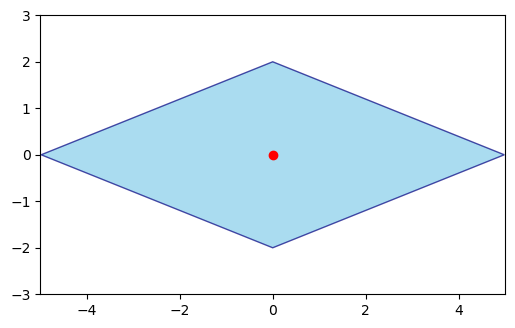

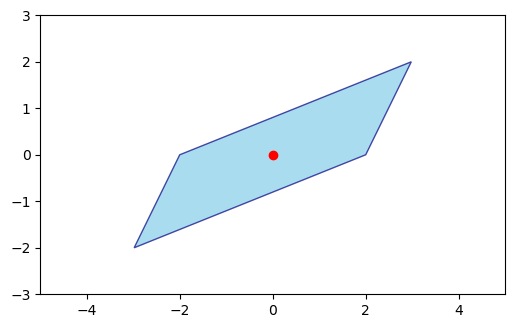

In [24]:
import matplotlib.animation

points = np.array([
    [0, 2],
    [2, 0],
    [0, -2],
    [-2, 0]
])

fig_rot, ax_rot = plt.subplots(figsize=(6,6))

def animate_rotation(i):
    ax_rot.clear()
    theta = np.deg2rad(i)
    A = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    pts = points @ A.T
    ax_rot.fill(pts[:,0], pts[:,1], color='skyblue', alpha=0.7, edgecolor='navy')
    ax_rot.scatter(0, 0, color='red')
    ax_rot.set_xlim(-3, 3)
    ax_rot.set_ylim(-3, 3)
    ax_rot.set_aspect('equal')

ani_rot = matplotlib.animation.FuncAnimation(fig_rot, animate_rotation, frames=np.arange(0, 361, 5), interval=100)
ani_rot.save("rotacja.gif", writer="imagemagick", fps=100)

fig_stretch, ax_stretch = plt.subplots(figsize=(6,6))

def animate_stretch(i):
    ax_stretch.clear()
    k = 1 + 0.01 * i  
    A = np.array([
        [k, 0],
        [0, 1]
    ])
    pts = points @ A.T
    ax_stretch.fill(pts[:,0], pts[:,1], color='skyblue', alpha=0.7, edgecolor='navy')
    ax_stretch.scatter(0, 0, color='red')
    ax_stretch.set_xlim(-5, 5)
    ax_stretch.set_ylim(-3, 3)
    ax_stretch.set_aspect('equal')

ani_stretch = matplotlib.animation.FuncAnimation(fig_stretch, animate_stretch, frames=range(0, 150), interval=50)
ani_stretch.save("rozciaganie.gif", writer="imagemagick", fps=100)

fig_shear, ax_shear = plt.subplots(figsize=(6,6))

def animate_shear(i):
    ax_shear.clear()
    k = 0.01 * i
    A = np.array([
        [1, k],
        [0, 1]
    ])
    pts = points @ A.T
    ax_shear.fill(pts[:,0], pts[:,1], color='skyblue', alpha=0.7, edgecolor='navy')
    ax_shear.scatter(0, 0, color='red')
    ax_shear.set_xlim(-5, 5)
    ax_shear.set_ylim(-3, 3)
    ax_shear.set_aspect('equal')

ani_shear = matplotlib.animation.FuncAnimation(fig_shear, animate_shear, frames=range(0, 150), interval=50)
ani_shear.save("pochylenie.gif", writer="imagemagick", fps=100)

plt.show()

### Zadanie 3 (przekształcenia afiniczne)

Przekształcenia afiniczne pozwalają na wykonywanie operacji _translacji_ i łączenia jej z innymi operacjami przekształcenia. 
Aby wykonać przekształcenie afiniczne należy zmienić reprezentację punktu $(x, y) \in R^2$ na $(x, y, 1) \in R^3$. W ten sposób macierz przekształceń osiąga wymiar 3x3. Macierz pozwalająca wykonanie operacji translacji (przesunięcie o wektor $[k_x, k_y]$) wygląda wtedy następująco:



$$
A_k = \begin{pmatrix}
1 & 0 & k_x \\
0 & 1 & k_y \\
0 & 0 & 1
\end{pmatrix}
$$


Pozostałe operacje analogicznie jak wcześniej, np. operacja obrotu:

$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta & 0\\
\text{sin}\theta & \text{cos}\theta & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Polecenie**

Wykonaj animację, gdzie operacja translacji oraz obrotu są wykonywane za pomocą jednej operacji macierzowej.

> Podpowiedź: należy "połączyć" macierze przekształceń w jedną.


Przykład:

<img src="./Figure_3.gif" height="300" width="300" />

MovieWriter imagemagick unavailable; using Pillow instead.


[[ 0.  2.  1.]
 [ 2.  0.  1.]
 [ 0. -2.  1.]
 [-2.  0.  1.]]


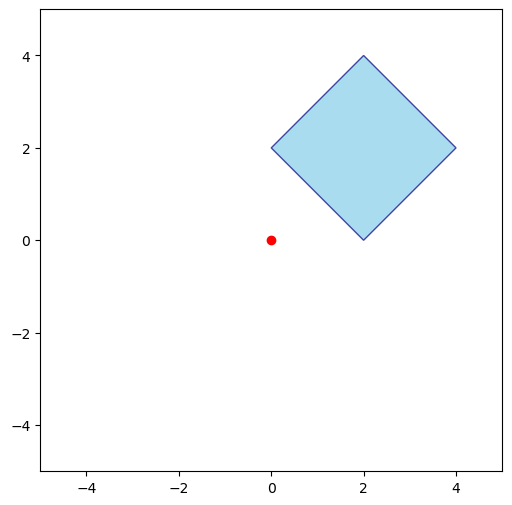

In [25]:
fig_affine, ax_affine = plt.subplots(figsize=(6,6))

points_h = np.hstack([points, np.ones((points.shape[0], 1))])
print(points_h)


def animate_affine(i):
    K = 2
    ax_affine.clear()
    theta = np.deg2rad(i)

    A_rot = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])

    A_trans = np.array([
        [1, 0, K],
        [0, 1, K],
        [0, 0, 1]
    ])

    A = A_rot @ A_trans
    # print(f"Ostateczna macierz: {A}")

    pts = (points_h @ A.T)[:, :2]
    ax_affine.fill(pts[:,0], pts[:,1], color='skyblue', alpha=0.7, edgecolor='navy')
    ax_affine.scatter(0, 0, color='red')
    ax_affine.set_xlim(-5, 5)
    ax_affine.set_ylim(-5, 5)
    ax_affine.set_aspect('equal')

ani_affine = matplotlib.animation.FuncAnimation(
    fig_affine, animate_affine, frames=np.arange(0, 361, 5), interval=100
)
ani_affine.save("afiniczne.gif", writer="imagemagick", fps=100)
plt.show()

### Zadanie 4 (przekształcenia macierzowe w 3D)

1) Utwórz prostą figurę geometryczną złożoną z 8 punktów w przestrzeni 3D (podobnie jak w pierwszym zadaniu).

Przykład:

```python
fig = plt.figure()
ax = Axes3D(fig)

m = np.array([
    [-1, -1, -1],
    [-1, 2, -1],
    [2, -1, -1],
    [2, 2, -1],
    [-1, -1, 2],
    [-1, 2, 2],
    [2, -1, 2],
    [2, 2, 2]
])

ax.scatter(m[:, 0], m[:, 1], m[:, 2])
```

2) Utwórz animację obrotu figury względem osi $0z$.

> Aby wykonać taki obrót należy użyć poniższej macierzy przekształceń:
$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta & 0\\
\text{sin}\theta & \text{cos}\theta & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Przykład**


<img src="./Figure_4.gif" height="300" width="300" />

MovieWriter imagemagick unavailable; using Pillow instead.


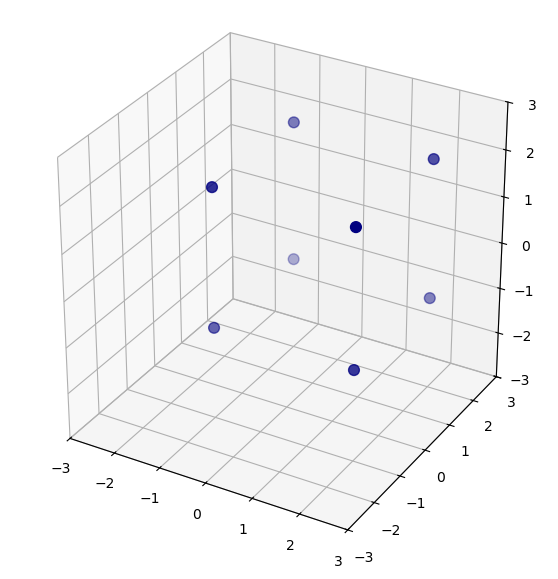

In [26]:
from mpl_toolkits.mplot3d import Axes3D

cube_points = np.array([
    [-1, -1, -1],
    [-1,  2, -1],
    [ 2, -1, -1],
    [ 2,  2, -1],
    [-1, -1,  2],
    [-1,  2,  2],
    [ 2, -1,  2],
    [ 2,  2,  2]
])

fig_3d = plt.figure(figsize=(7,7))
ax_3d = fig_3d.add_subplot(111, projection='3d')

def animate_cube_rotation(i):
    ax_3d.clear()
    theta = np.deg2rad(i)
    A = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])

    rotated = cube_points @ A.T
    
    ax_3d.scatter(rotated[:,0], rotated[:,1], rotated[:,2], color='navy', s=60)
    ax_3d.set_xlim(-3, 3)
    ax_3d.set_ylim(-3, 3)
    ax_3d.set_zlim(-3, 3)
    ax_3d.set_box_aspect([1,1,1])

ani_cube = matplotlib.animation.FuncAnimation(
    fig_3d, animate_cube_rotation, frames=np.arange(0, 361, 5), interval=100
)
ani_cube.save("rotacja_cube.gif", writer="imagemagick", fps=100)
plt.show()

### Zadanie 5

Połącz punkty (jeżeli nie zrobiłeś tego wcześniej) figury z poprzedniego zadania.

<img src="./Figure_5.gif" height="300" width="300" />

In [ ]:
cube_edges = [
    (0,1), (0,2), (0,4),
    (1,3), (1,5),
    (2,3), (2,6),
    (3,7),
    (4,5), (4,6),
    (5,7),
    (6,7)
]

def animate_cube_edge_rotation(i):
    ax_3d.clear()
    theta = np.deg2rad(i)
    A = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    
    rotated = cube_points @ A.T
    
    ax_3d.scatter(rotated[:,0], rotated[:,1], rotated[:,2], color='navy', s=60)
    
    for edge in cube_edges:
        xs = [rotated[edge[0],0], rotated[edge[1],0]]
        ys = [rotated[edge[0],1], rotated[edge[1],1]]
        zs = [rotated[edge[0],2], rotated[edge[1],2]]
    
        ax_3d.plot(xs, ys, zs, color='skyblue')
    
    ax_3d.set_xlim(-3, 3)
    ax_3d.set_ylim(-3, 3)
    ax_3d.set_zlim(-3, 3)
    ax_3d.set_box_aspect([1,1,1])

ani_cube = matplotlib.animation.FuncAnimation(
    fig_3d, animate_cube_edge_rotation, frames=np.arange(0, 361, 5), interval=100
)
ani_cube.save("rotacja_cube_edge.gif", writer="imagemagick", fps=100)
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.
